# ICS 604: APPLIED DATA SCIENCE

## Logistic Regression

---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Logistic Regression

Logistic regression is a fundamental technique used when the response variable is qualitative rather than quantitative. While linear regression is designed to predict continuous numerical outcomes, logistic regression is used when the goal is to predict categories. For example, instead of estimating a numeric value, we might want to determine whether an email is spam or not, or whether an individual is likely to develop a disease. In such cases, the outcome belongs to a discrete set of categories, making logistic regression a natural choice.

At its core, logistic regression is a classification method. Classification involves taking a set of input features and assigning them to a qualitative outcome, meaning one of several predefined categories. These categories could be binary (such as spam vs. ham) or more complex with multiple classes. Beyond simply assigning a label, logistic regression is particularly useful because it can estimate probabilities. For instance, instead of just predicting that a computer is infected, the model might output a 0.99 probability versus a 0.52 probability, giving a clearer sense of confidence in the prediction. Typically, the final classification is made by selecting the category with the highest predicted probability.

There are two main types of logistic regression: binary and multiclass. Binary logistic regression deals with problems that have only two possible outcomes, such as yes/no or true/false scenarios. Multiclass logistic regression extends this idea to handle more than two categories. In many introductory contexts, the focus is on binary logistic regression because it is simpler to understand and serves as a foundation for more complex extensions.

### Dataset 

The dataset shown represents a classic binary classification problem: predicting whether a person will default on their credit card payment. Each point in the plot corresponds to an individual, with features such as balance or income determining its position. The two classes are visually distinguished — brown marks indicate individuals who default, while blue circles represent those who do not. The goal is to build a model that can learn from this data and accurately separate these two groups, allowing us to predict the likelihood of default for new individuals.

<center><img src="https://www.dropbox.com/scl/fi/yry0choh0w4nuamp0ohoe/default_data.png?rlkey=fpuvcamigtr7c79f9szo4m54g&st=a5ljrcdu&dl=1" alt="drawing" style="width:500px;"/></center>

### Justification for Logistic Regression

A natural question is whether linear regression could be used for this task. One possible approach is to encode the two classes numerically, assigning a value of 1 to individuals who default and 0 to those who do not. A linear regression model could then be trained to predict values within this range. To turn these predictions into class labels, we could apply a threshold — for example, classifying any predicted value above 0.5 as a default (1) and anything below as non-default (0). This effectively “hacks” linear regression into a classification tool.

<center><img src="https://www.dropbox.com/scl/fi/gbrtblecxl64hwtq6olrk/regression_2.png?rlkey=nalk3oejd1zx7k9c0yowszgq5&st=2o7gysx2&dl=1" width="400"/></center>
<center>Using Linear Regression in Classification — Model</center><br><br>


<center><img src="https://www.dropbox.com/scl/fi/ra1qrp78u3ozikrhiposq/regression_3.png?rlkey=t0rn3cyb565bfjxqn9lzojmer&st=8n7bfv89&dl=1" alt="drawing" style="width:400px;"/></center>
<center>Using Linear Regression in Classification — Prediction</center><br><br>


<center><img src="https://www.dropbox.com/scl/fi/azjlzrc0ju2pwe58slvyb/regression_4.png?rlkey=4rh9lt67j358nkhe5vpunf44f&st=j5o21bd2&dl=1" alt="drawing" style="width:400px;"/></center>
<center>Using Linear Regression in Classification — Prediction Regions</center><br><br>


However, this approach has several important limitations. Linear regression is inherently designed to predict continuous values, not probabilities or discrete classes. As a result, its predictions can fall outside the [0,1] range, producing values that are difficult — or even impossible — to interpret as probabilities. Additionally, the regression line is highly sensitive to the data, particularly to outliers. A few extreme points can significantly shift the line, which in turn affects where the threshold intersects and leads to unstable or misleading classifications.

<center><img src="https://www.dropbox.com/scl/fi/31wtam5i4y11t0rgipn1a/regression_5.png?rlkey=j32lvurlhueynonmnknmzkcld&st=h2mgypuc&dl=1" alt="drawing" style="width:400px;"/></center><br>

These shortcomings highlight why logistic regression is preferred for classification problems. Unlike linear regression, logistic regression is specifically designed to model probabilities and ensures that outputs remain within the valid range of 0 to 1. It also produces a more appropriate decision boundary for separating classes, making it a more robust and interpretable choice for problems like credit card default prediction.

### Logistic Regression

Logistic regression is one of the simplest yet most widely used methods for classification problems. Its popularity comes from both its interpretability and its ability to model probabilities directly. Unlike linear regression, which can produce any real-valued output, logistic regression constrains its predictions to lie between 0 and 1. This makes its outputs naturally interpretable as probabilities, allowing us to estimate how likely a given input belongs to a particular class.

At the heart of logistic regression is the logistic (or sigmoid) function, which transforms a linear combination of input features into a value between 0 and 1. The model first computes a linear expression, $\beta_0 + \beta_1x$, and then passes it through the sigmoid function:
$$ g(x) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x)}}$$

This function has an “S-shaped” curve, smoothly transitioning from values close to 0 for very negative inputs to values close to 1 for very positive inputs. If we assume $\beta_0=0$ and $\beta_1=1$, the function simplifies to a standard sigmoid centered at zero, where inputs near zero map to probabilities around 0.5.

<center><img src="https://www.dropbox.com/scl/fi/binaa1n8clt68z7ow7mob/logistic_regression.png?rlkey=q6a3xj8dr6upqy0bypfg8fpld&st=r38tvti8&dl=1" alt="drawing" style="width:500px;"/></center><br>

The output of the logistic function, $g(x)$, can be interpreted as the probability that the response variable $y$ equals 1 given the input $x$ and the model parameters. In other words, it estimates $P(y=1∣x, \beta_0, \beta_1)$. To make a classification decision, we typically apply a threshold (commonly 0.5): if the predicted probability is greater than the threshold, we classify the input as class 1; otherwise, we classify it as class 0. This probabilistic framework makes logistic regression both intuitive and powerful for binary classification tasks.

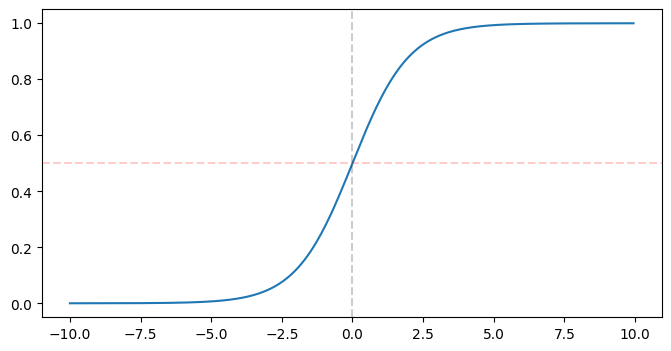

In [13]:
x_axis = np.arange(-10, 10, 0.05)
y_axis = 1 / (1 + np.e**-x_axis)

plt.figure(figsize=(8, 4))
plt.plot(x_axis, y_axis)
plt.axhline(0.5, linestyle="--", color='r', alpha=0.2)
plt.axvline(0, linestyle="--", color='k', alpha=0.2);

### Parameters of the Logstic Regression

In logistic regression, the parameters $\beta_0$ (intercept) and $\beta_1$ (slope) play a crucial role in shaping how the model separates classes. Similar to linear regression, these parameters are not fixed — they can take on any real values, and the learning process aims to find the combination that best fits the data.

#### Changing $\beta_0$

The parameter $\beta_0$, often called the intercept, controls the horizontal position of the sigmoid (logistic) curve. Changing $\beta_0$ shifts the entire curve to the left or right without altering its overall shape. This effectively adjusts the point at which the predicted probability is 0.5, which corresponds to the decision boundary in binary classification. A positive $\beta_0$ shifts the curve in one direction, while a negative value shifts it in the opposite direction, changing where the model transitions between predicting class 0 and class 1.

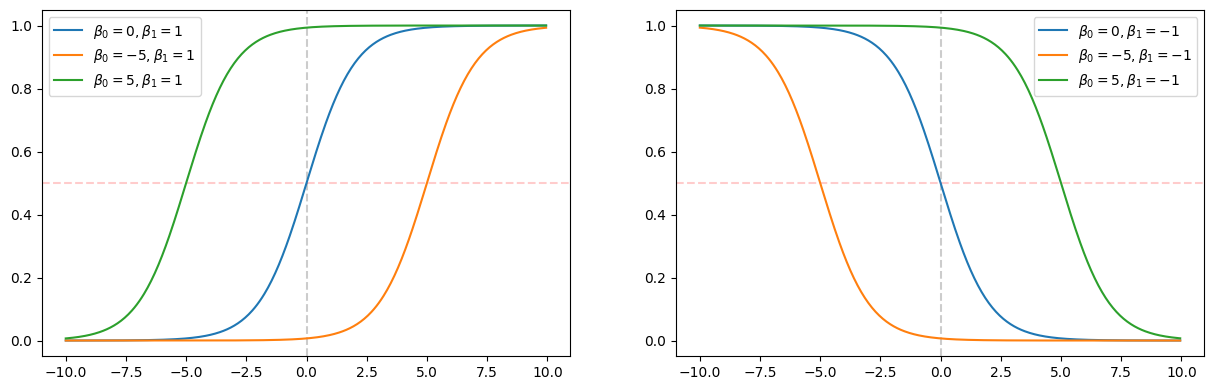

In [14]:
plt.figure(figsize=(15, 4.5))

x = np.arange(-10, 10, 0.05)

for i, b1 in enumerate([1, -1]):
    plt.subplot(1, 2, i+1)
    plt.axhline(0.5, linestyle="--", color='r', alpha=0.2)
    plt.axvline(0, linestyle="--", color='k', alpha=0.2)
    
    for b0 in [0, -5, 5]:
        beta_0, beta_1 = (b0, b1) 
        y = 1 / (1 + np.e**-(beta_0 + beta_1*x))
        plt.plot(x, y, label = r'$\beta_0 = {}, \beta_1 = {}$'.format(beta_0, beta_1))
        plt.legend()

#### Changing $\beta_1$

On the other hand, $\beta_1$ determines the steepness or slope of the curve. When $\beta_1$ has a large magnitude, the sigmoid function becomes steeper, meaning the transition from probabilities near 0 to probabilities near 1 happens more abruptly. This reflects a model that is more “confident” in its predictions over a narrow range of input values. Conversely, when $\beta_1$ is small in magnitude, the curve becomes flatter, and the transition between classes is more gradual, indicating greater uncertainty across a wider range of inputs.

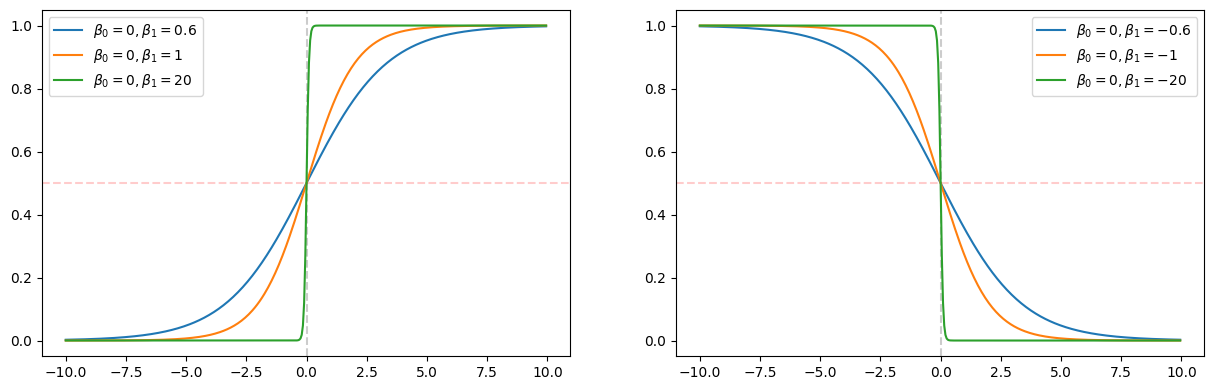

In [15]:
plt.figure(figsize=(15, 4.5))

x = np.arange(-10, 10, 0.05)

for i, t in enumerate([1, -1]):
    plt.subplot(1, 2, i+1)
    plt.axhline(0.5, linestyle="--", color='r', alpha=0.2)
    plt.axvline(0, linestyle="--", color='k', alpha=0.2)
    
    for b1 in [0.6, 1, 20]:
        beta_0, beta_1 = (0, t*b1)
        y = 1 / (1 + np.e **-(beta_0 + beta_1*x))
        plt.plot(x, y, label = r'$\beta_0 = {}, \beta_1 = {}$'.format(beta_0, beta_1))
        plt.legend()

Together, $\beta_0$ and $\beta_1$ define both the position and shape of the decision boundary. By adjusting these parameters, logistic regression can flexibly model how input features relate to the probability of belonging to a particular class, allowing it to capture a wide range of classification patterns.

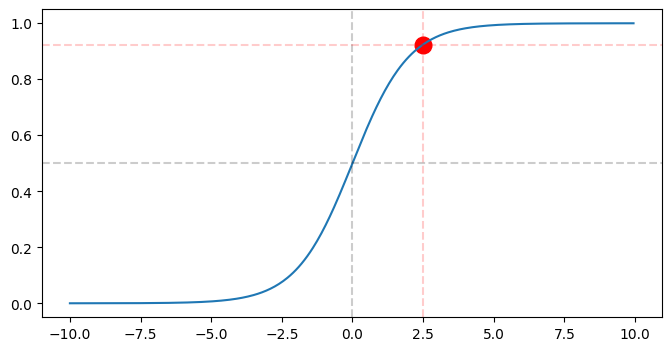

In [16]:
x_axis = np.arange(-10, 10, 0.05)
y_axis = 1 / (1 + np.e**-x_axis)

plt.figure(figsize=(8, 4))
plt.plot([2.5], [1 / (1 + np.e**-2.5)], 'or', markersize=12)

plt.plot(x_axis, y_axis)
plt.axhline(0.5, linestyle="--", color='k', alpha=0.2)
plt.axvline(0, linestyle="--", color='k', alpha=0.2)

plt.axhline(1 / (1 + np.e**-2.5), linestyle="--", color='r', alpha=0.2)
plt.axvline(2.5, linestyle="--", color='r', alpha=0.2);

### Fitting the Model

Fitting a logistic regression model follows a similar high-level idea to linear regression: we use data to estimate the parameters of the model. In linear regression, this is done by finding the line that minimizes the residual sum of squares (RSS), meaning the model that produces predictions closest to the observed values. However, this approach does not translate well to classification problems, where the outputs are discrete (0 or 1) rather than continuous.

In binary logistic regression, both the true outcomes and the predictions are interpreted in terms of probabilities for class membership. A naive idea might be to directly minimize the difference between predicted probabilities $g(x_i)$ and actual labels $y_i$, similar to linear regression:

$$
\frac{1}{n} \sum_{i=1}^n (g(x_i) - y_i).
$$

However, this leads to a non-convex optimization problem, which is problematic because it does not guarantee convergence to a global minimum. In practice, this makes the learning process unstable and unreliable.

To address this, logistic regression uses a different cost function based on the concept of likelihood, often referred to as the **log loss** or **cross-entropy loss**. For a single data point, the cost is defined as:

$$
    cost(g(x),y) = \left\{
    \begin{array}{ll}
        -\log(g(x)) & \mbox{ if }  y = 1 \\
        -\log(1 - g(x)) & \mbox{ if }  y = 0 \\
    \end{array}
\right.
$$

This can be written more compactly as:

$$cost(g(x), y) = -[y\log(g(x)) + (1 - y)\log(1 - g(x))]$$

Here, $g(x)$ represents the predicted probability that $y=1$. This formulation has desirable mathematical properties, most importantly that it is convex, ensuring that optimization algorithms can reliably find the global minimum.

The behavior of this cost function aligns well with intuition. When $y=1$, the cost becomes $−\log(g(x))$, which is very small when the predicted probability is close to 1 and grows rapidly as the prediction approaches 0. In fact, predicting a probability near 0 for a true class of 1 results in a very large penalty. Similarly, when $y=0$, the cost becomes $−\log(1−g(x))$, which penalizes predictions that incorrectly assign high probability to class 1. In both cases, correct and confident predictions incur very little cost, while confident but incorrect predictions are heavily penalized.

In [17]:
print(np.log(1), -np.log(0.5), -np.log(0.1), -np.log(0.00000001) )

0.0 0.6931471805599453 2.3025850929940455 18.420680743952367


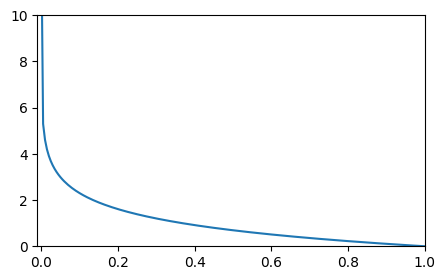

In [18]:
# -log(x): cost function when y=1

x_axis = np.arange(0.000001, 1.1, 0.005)
y_axis = -np.log(x_axis)

plt.figure(figsize=(5, 3))
plt.plot(x_axis, y_axis)
plt.xlim(-0.01, 1)
plt.ylim(0, 10);

In [19]:
print(np.log(1 - 0), -np.log(1 - 0.2), -np.log(1 - 0.5), -np.log(1 - 0.99999999))

0.0 0.2231435513142097 0.6931471805599453 18.420680738927608


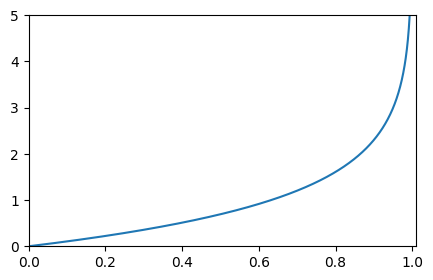

In [20]:
# -log(1-x): cost function when y=0

x_axis = np.arange(0, 0.9999999, 0.0005)
y_axis = -np.log(1 - x_axis)

plt.figure(figsize=(5, 3))
plt.plot(x_axis, y_axis)
plt.xlim(0, 1.01)
plt.ylim(0, 5);

### Training and Prediction

Training the model involves finding the parameters $\beta_0$ and $\beta_1$ that minimize the average cost across all training examples:

$$ 
\frac{1}{n}\sum_{i=1}^n cost\left(g(x_i),y_i\right) \\
= \frac{1}{n}\sum_{i=1}^n -[y_i\log(g(x_i)) + (1 - y_i)\log(1 - g(x_i))]
$$

This is typically done using optimization algorithms such as gradient descent. Once the optimal parameters are found, the model can be used for prediction. Given a new input $x$, the model computes:

$$ p(y=1| x, \beta_0,\beta_1) = g(x) = \frac{1}{1+e^{-(\beta_0+\beta_1 x)}} $$

This gives the probability that the input belongs to class 1. The probability of class 0 is simply $1−g(x)$. By applying a threshold (commonly 0.5), we can convert these probabilities into final class predictions.

## Recall: Dataset 

The two classes are visually distinguished — brown marks indicate individuals who default, while blue circles represent those who do not.

<center><img src="https://www.dropbox.com/scl/fi/yry0choh0w4nuamp0ohoe/default_data.png?rlkey=fpuvcamigtr7c79f9szo4m54g&st=acwrlb3h&dl=1" alt="drawing" style="width:500px;"/>


In [21]:
try:
    import openpyxl
except ModuleNotFoundError:
    !pip install openpyxl

In [22]:
data = pd.read_excel("Default.xlsx")
data.head()

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [23]:
data = data.drop(columns=data.columns[0])
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [24]:
data["encoded_default"] = data["default"].map({"No":0, "Yes":1})
data.head()

,default,student,balance,income,encoded_default
0,No,No,729.526495,44361.625074,0
1,No,Yes,817.180407,12106.134700,0
2,No,No,1073.549164,31767.138947,0
3,No,No,529.250605,35704.493935,0
4,No,No,785.655883,38463.495879,0


### Logistic Regression with Scikit-Learn

In practice, logistic regression models are rarely fit “by hand.” Instead, libraries like Scikit-learn provide efficient implementations that automatically estimate the optimal parameters $\beta_0$ and $\beta_1$ from data. Given a dataset — for example, where the input feature is a person’s credit card balance and the output indicates whether they default — the model learns the relationship between these variables by fitting the logistic function.

Using this framework, the model can be written as:

$$
p(\mbox{default}=1| x, \beta_0, \beta_1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 \cdot balance)}} + \epsilon
$$

Here, the sigmoid function transforms the linear combination of inputs into a probability between 0 and 1, representing the likelihood of default. The parameters $\beta_0$ (intercept) and $\beta_1$ (coefficient for balance) are learned directly from the training data through optimization.

As with linear regression, the term $\epsilon$ represents noise — capturing variability in the data that cannot be explained by the model. This could include unobserved factors such as spending habits, financial stability, or unexpected life events that influence whether someone defaults. While the model aims to capture the main trend in the data, it cannot perfectly account for all real-world complexity.

Once trained, the scikit-learn logistic regression model can be used to predict probabilities of default for new individuals based on their balance. These probabilities can then be converted into classifications (default vs. no default) using a threshold, making the approach both practical and interpretable for decision-making tasks.

In [25]:
data.loc[:, "balance"]

0        729.526495
1        817.180407
2       1073.549164
3        529.250605
4        785.655883
           ...     
9995     711.555020
9996     757.962918
9997     845.411989
9998    1569.009053
9999     200.922183
Name: balance, Length: 10000, dtype: float64

In [26]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

X = data["balance"].values.reshape(-1, 1) 
Y = data["encoded_default"].values 

logreg.fit(X, Y)
logreg.coef_, logreg.intercept_

(array([[0.00549892]]), array([-10.65132824]))

In [27]:
logreg.predict_proba(np.array([[1], [2000]]))

array([[9.99976201e-01, 2.37993302e-05],
       [4.14230725e-01, 5.85769275e-01]])

### Model Interpretation

Interpreting a logistic regression model involves understanding how the input features influence the predicted probability of an outcome — in this case, whether a person defaults on their credit card payment.

#### Interpretation — Balance

Consider the model:

$$
p(\mbox{default}=1| x, \beta_0, \beta_1) \approx \frac{1}{1 + e^{-(-10.6513 + 0.0055 \times balance)}}
$$

Here, the coefficient $\beta_1=0.005$ represents the effect of the *balance* variable (measured in dollars) on the log-odds of default. A positive coefficient means that as the balance increases, the probability of default also increases. However, this relationship is not linear in probability space — it follows the S-shaped logistic curve.

For very small balances, the predicted probability of default is extremely low. For example, at a balance of $1:

$$
p(\mbox{default}=1| x=1, \beta_0=-10.65, \beta_1=0.005) \approx \frac{1}{1 + e^{10.6513 - 0.0055 \times 1}} \approx 0.000024
$$

This indicates a near-zero chance of default.

In contrast, for a much larger balance such as $2,000:

$$
p(\mbox{default}=1| x=2000, \beta_0=-10.65, \beta_1=0.005) \approx \frac{1}{1 + e^{10.6513 - 0.0055 \times 2000}} \approx 0.586
$$

Now the probability exceeds 50%, meaning the model would likely classify this individual as a defaulter. This demonstrates how increases in balance can dramatically shift predicted risk, especially in the mid-range of the sigmoid curve.

#### Interpretation — Student Status

In [28]:
data["encoded_student"] = data["student"].map({"No":0, "Yes":1})
data.head()

,default,student,balance,income,encoded_default,encoded_student
0,No,No,729.526495,44361.625074,0,0
1,No,Yes,817.180407,12106.134700,0,1
2,No,No,1073.549164,31767.138947,0,0
3,No,No,529.250605,35704.493935,0,0
4,No,No,785.655883,38463.495879,0,0


In [29]:
X = data["encoded_student"].values.reshape(-1, 1)
y = data["encoded_default"].values

logreg.fit(X, Y)
logreg.coef_, logreg.intercept_

(array([[0.39620888]]), array([-3.50257249]))

In [30]:
logreg.predict_proba(np.array([[0], [1]]))

array([[0.97076088, 0.02923912],
       [0.95715448, 0.04284552]])


Now consider a different model using a binary feature indicating student status:

$$
p(\mbox{default}=1| x, \beta_0, \beta_1) \approx \frac{1}{1 + e^{-(-3.5 + 0.4 \times student)}}
$$

Here, the variable $student$ is encoded as 1 for students and 0 for non-students. The coefficient $\beta_1=0.4$ suggests that being a student slightly increases the log-odds of default compared to non-students.

For a student ($x=1$):

$$
p(\mbox{default}=1| x=1, \beta_0=-3.5, \beta_1=0.4) \approx \frac{1}{1 + e^{3.5 - 0.4 \times 1}} \approx 0.043
$$


For a non-student ($x=0$):

$$
p(\mbox{default}=1 | x=0, \beta_0=-3.5, \beta_1=0.4) \approx \frac{1}{1 + e^{3.5 - 0.4 \times 0}} \approx 0.029
$$

While both probabilities are relatively low, students have a somewhat higher predicted probability of default than non-students according to this model.

In [31]:
student_default = ((data["encoded_student"] == 1) & (data["encoded_default"] == 1)).sum()
non_student_default = ((data["encoded_student"] == 0) & (data["encoded_default"] == 1)).sum()

total_student = (data["encoded_student"] == 1).sum()
total_non_student = (data["encoded_student"] == 0).sum()

print(f"Total sample: {len(data)} (Student = {total_student}, Non-student = {total_non_student})")
print(f"Number of student defaulting: {student_default}")
print(f"Number of non-student defaulting: {non_student_default}\n")

print(f'Students defaulting ratio: {student_default / total_student:.4f}')
print(f'Students not defaulting ratio: {1 - student_default / total_student:.4f}')
print(f'Non-students defaulting ratio: {non_student_default / total_non_student:.4f}')
print(f'Non-students defaulting ratio: {1 - non_student_default / total_non_student:.4f}')

Total sample: 10000 (Student = 2944, Non-student = 7056)
Number of student defaulting: 127
Number of non-student defaulting: 206

Students defaulting ratio: 0.0431
Students not defaulting ratio: 0.9569
Non-students defaulting ratio: 0.0292
Non-students defaulting ratio: 0.9708


#### Key Takeaways

These examples highlight how logistic regression translates feature values into probabilities. Continuous variables like balance can have a large and nonlinear impact across their range, while binary variables like student status shift the probability more modestly. Importantly, coefficients in logistic regression are best interpreted in terms of their effect on log-odds, but examining predicted probabilities at meaningful values (as done here) often provides more intuitive insight.

### Multiple Logistic Regression

Multiple logistic regression extends the basic logistic regression framework by incorporating more than one predictor variable. Instead of modeling the probability of an outcome using a single feature, the model combines several inputs — such as balance, income, student status, age, or number of credit applications — into a single equation. This allows the model to capture more complex relationships and typically results in better discrimination between classes. Like linear regression, it forms a linear combination of the inputs, but then applies the logistic (sigmoid) function to convert that combination into a probability between 0 and 1.

The general form of the model is:

$$
 \text{logit}(p) = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n
$$  

where $p$ is the probability of the outcome (e.g., default = 1), the $\beta_i$ values are the coefficients, and the $x_i$ are the predictor variables. Each coefficient represents the contribution of its corresponding feature to the log-odds of the outcome, holding all other variables constant. This “all else equal” interpretation is key when working with multiple predictors.

### Inspecting the Contribution of Income

<img src="https://www.dropbox.com/scl/fi/jzxrdf9hiad32mqs9as5t/classification_1.png?rlkey=6exka5790x7kzw2asmzkvfe1j&st=u5o2tjmc&dl=1" alt="drawing" style="width:1000px;"/><br>

When inspecting the contribution of income, the visual plot may suggest that income alone does not clearly separate defaulters from non-defaulters. In other words, if you look at income in isolation, it might not appear to be a strong predictor. However, the logistic regression model provides a more nuanced view by considering income alongside other variables like balance.

In [32]:
X = data[['balance', 'income']]
y = data["encoded_default"].values

logreg.fit(X, Y)
logreg.coef_, logreg.intercept_

(array([[5.64710265e-03, 2.08089741e-05]]), array([-11.54046792]))

<br>
From the model:

$$
p(\mbox{default}=1| x, \beta_0, \beta_1, \beta_2) \approx \frac{1}{1 + e^{-(-11.54047 + 0.00565 \times balance + 0.00002 \times income)}}
$$

we see that the coefficient for income is 0.00002. This value is very small in magnitude, indicating that income has only a minor effect on the probability of default compared to balance (which has a much larger coefficient of 0.00565). The positive sign suggests that higher income is associated with a very slight increase in the probability of default, but the effect is negligible in practical terms. It is also worth noting that this positive sign may reflect relationships between income and other predictors in the model (such as balance), rather than a purely independent effect — coefficients in multiple regression capture the effect of a variable holding others constant, and can sometimes differ from intuitive expectations based on simple relationships.

This highlights an important insight: even if a variable does not appear useful when viewed alone, it may still contribute marginally when combined with other predictors. In this case, income does have a statistically measurable effect, but its practical impact on predictions is quite small relative to more influential variables like balance.

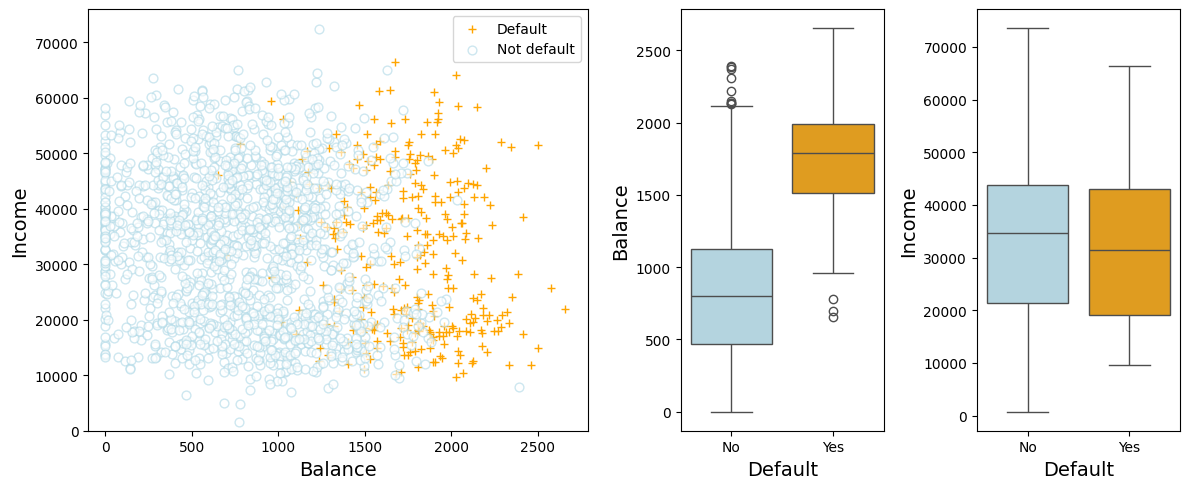

In [34]:
import matplotlib as mpl
import seaborn as sns

fig = plt.figure(figsize=(12, 5))
gs = mpl.gridspec.GridSpec(1, 4)
ax1 = plt.subplot(gs[0, :-2])
ax2 = plt.subplot(gs[0, -2])
ax3 = plt.subplot(gs[0, -1])

# Take a fraction of the samples where target value (default) is 'no'
df_no = data[data["encoded_default"] == 0].sample(frac=0.15)

# Take all samples  where target value is 'yes'
df_yes = data[data["encoded_default"] == 1]

df_ = pd.concat([df_no, df_yes])

ax1.scatter(df_[df_.default == 'Yes'].balance, df_[df_.default == 'Yes'].income, 
            s=40, c='orange', marker='+', linewidths=1, label='Default')
ax1.scatter(df_[df_.default == 'No'].balance, df_[df_.default == 'No'].income, s=40,
            edgecolors='lightblue', marker='o', linewidths=1, 
            facecolors='white', alpha=.6, label='Not default')
ax1.set_ylim(ymin=0)
ax1.set_ylabel('Income', fontsize=14)
ax1.set_xlim(xmin=-100)
ax1.set_xlabel('Balance', fontsize=14)
ax1.legend(loc='upper right')

c_palette = {'No':'lightblue', 'Yes':'orange'}
sns.boxplot(x='default', y='balance', data=data, hue='default', 
            legend=False, orient='v', ax=ax2, palette=c_palette)
ax2.set_xlabel('Default', fontsize=14)
ax2.set_ylabel('Balance', fontsize=14)

sns.boxplot(x='default', y='income', data=data, hue='default', 
            legend=False, orient='v', ax=ax3, palette=c_palette)
ax3.set_xlabel('Default', fontsize=14)
ax3.set_ylabel('Income', fontsize=14)

gs.tight_layout(plt.gcf())

### Relationship Between Logistic and Linear Regression Model

The relationship between logistic regression and linear regression becomes clearer when we rewrite the logistic model in different forms. Starting from the probability function:

$$p(x) = \frac{1}{1+e^{-(\beta_0 + \beta_1 x)}}$$

we can express it equivalently as:

$$p(x) = \frac{e^{(\beta_0 + \beta_1 x)}}{1+e^{(\beta_0 + \beta_1 x)}}$$

From this, we derive an important quantity:

$$\frac{p(x)}{1-p(x)} = e^{(\beta_0 + \beta_1 x)}$$

This ratio $\frac{p(x)}{1-p(x)}$ is known as the **odds**. Unlike probabilities, which range between 0 and 1, odds range from 0 to infinity. For example, if $p(x)=0.2$, then the odds are:

$$ \frac{0.2}{0.8} = \frac{1}{4} $$

This means that for every one person who defaults, four do not. Probability and odds describe the same situation but in different ways — probability gives a proportion, while odds give a ratio of occurrences.

Taking the natural logarithm of both sides of the equation gives:

$$\log\left(\frac{p(x)}{1-p(x)}\right) =\beta_0 + \beta_1x$$

The left-hand side is called the **log-odds** or **logit**. This transformation is key: while the probability $p(x)$ is nonlinear in $x$, the log-odds are *linear* in $x$. This is where logistic regression connects to linear regression — the model is linear, but in the log-odds space rather than directly on the outcome.

This distinction is crucial for interpretation. In linear regression, $\beta_1$ represents the change in the response variable for a one-unit increase in $x$. In logistic regression, however, $\beta_1$ represents the change in the *log-odds* of the outcome for a one-unit increase in $x$. Equivalently, $e^{\beta_1}$ represents the multiplicative change in the odds for a one-unit increase in $x$.

So while both models use a linear structure, logistic regression applies it in a transformed space, allowing it to model probabilities in a way that remains bounded between 0 and 1 while still leveraging linear relationships.